In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

print(X.shape)
print(wine.feature_names)
print(wine.target_names)

(178, 13)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


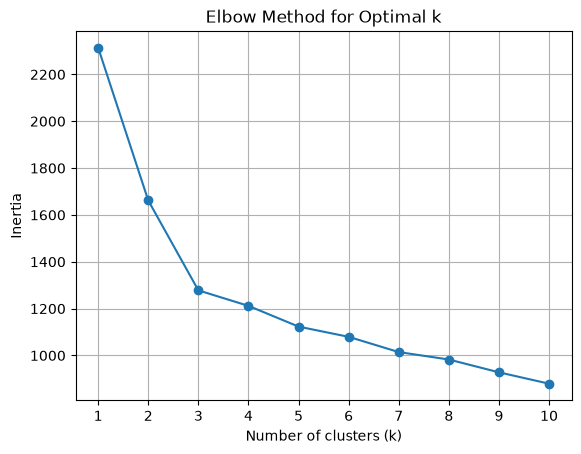

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

ks = range(1, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_X)
    inertias.append(kmeans.inertia_)
    
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.grid()
plt.show()

In [8]:
# Crosstabulation of clusters with actual wine classes
optimal_k = 3  # Based on the elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(scaled_X)

actual_varieties = [wine.target_names[i] for i in y]
df = pd.DataFrame({'Actual Variety': actual_varieties, 'Cluster': kmeans.labels_})
crosstab = pd.crosstab(df['Actual Variety'], df['Cluster'])
print(crosstab)


Cluster          0   1   2
Actual Variety            
class_0          0   0  59
class_1         65   3   3
class_2          0  48   0


### Hierarchical clustering

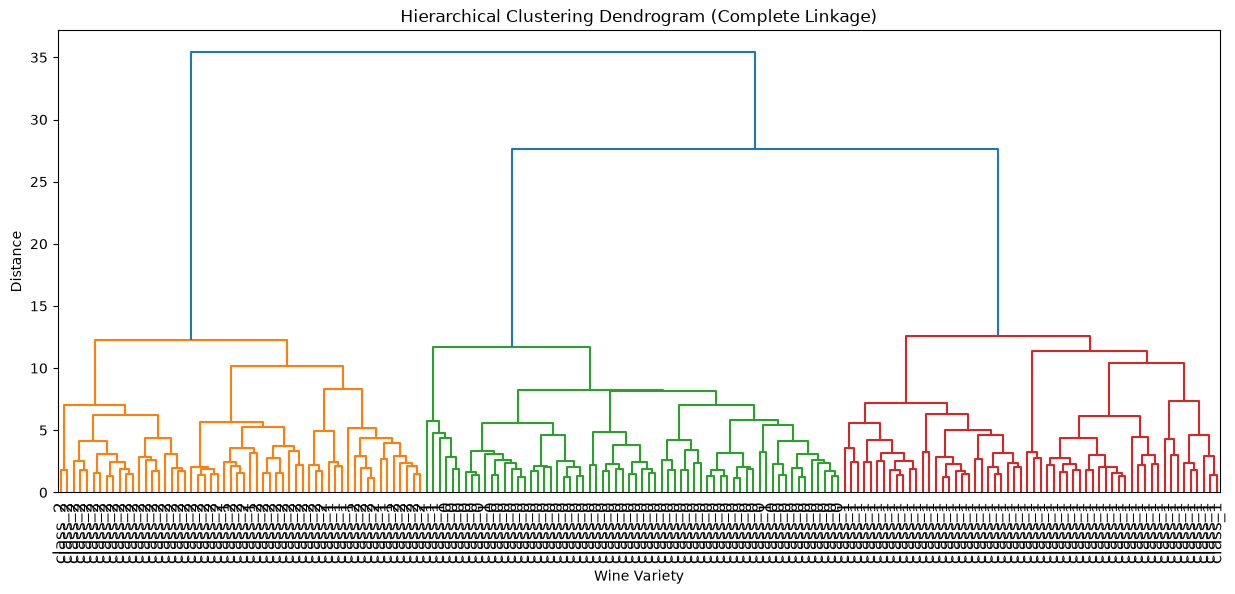

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

merging_matrix = linkage(scaled_X, method='ward')
plt.figure(figsize=(15, 6))

dendrogram(merging_matrix, labels=actual_varieties,
        leaf_rotation=90, leaf_font_size=12)

plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Wine Variety')
plt.ylabel('Distance')
plt.show()

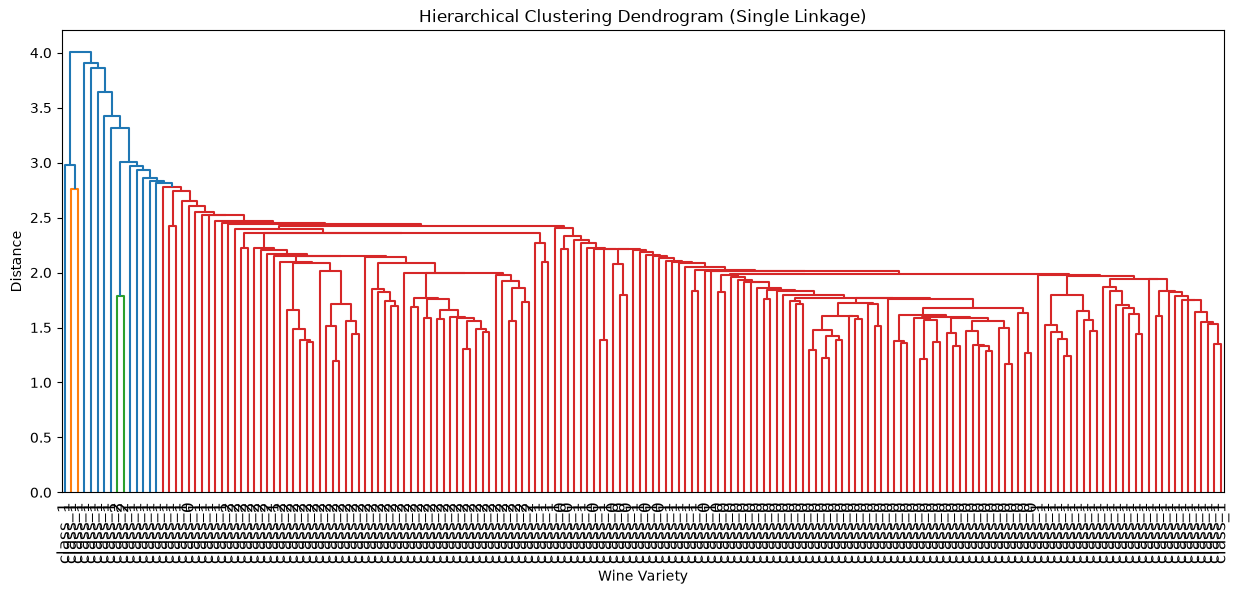

In [16]:
# with single linkage
merging_matrix_single = linkage(scaled_X, method='single')
plt.figure(figsize=(15, 6))
dendrogram(merging_matrix_single, labels=actual_varieties,
        leaf_rotation=90, leaf_font_size=12)

plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Wine Variety')
plt.ylabel('Distance')
plt.show()

In [17]:
# use fcluster to assign cluster labels
from scipy.cluster.hierarchy import fcluster

labels = fcluster(merging_matrix, t=3, criterion='maxclust')  # t=3 for 3 clusters

df = pd.DataFrame({'Actual Variety': actual_varieties, 'Cluster': labels})
ct = pd.crosstab(df['Actual Variety'], df['Cluster'])
print(ct)

Cluster          1   2   3
Actual Variety            
class_0          0  59   0
class_1          8   5  58
class_2         48   0   0


### t-SNE

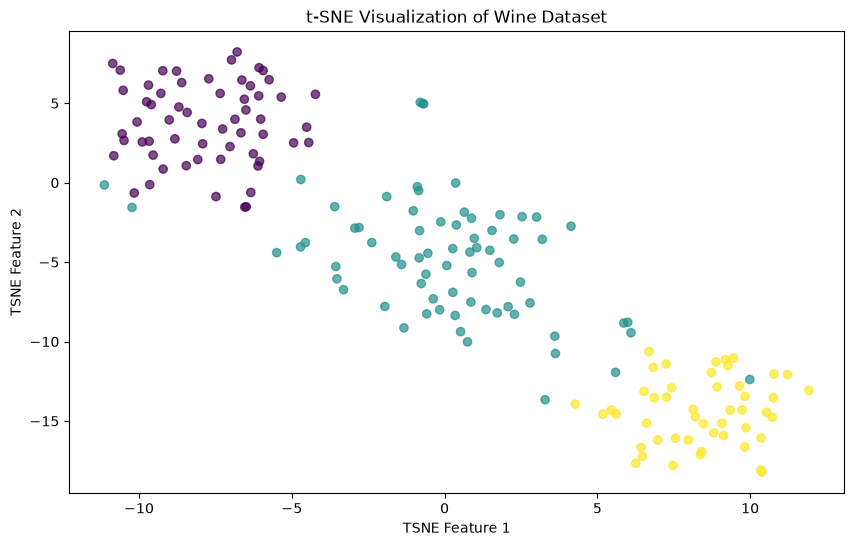

In [19]:
from sklearn.manifold import TSNE

model = TSNE(learning_rate=100, random_state=42)
tsne_features = model.fit_transform(scaled_X)

xs = tsne_features[:, 0]
ys = tsne_features[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(xs, ys, c=y, cmap='viridis', alpha=0.7)
plt.xlabel('TSNE Feature 1')
plt.ylabel('TSNE Feature 2')
plt.title('t-SNE Visualization of Wine Dataset')
plt.show()

### PCA Transformation

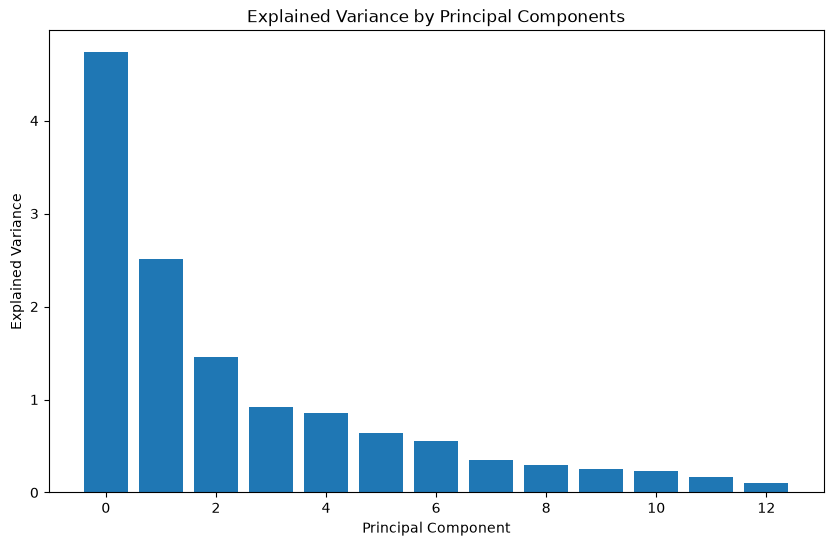

In [20]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_X)

features = range(pca.n_components_)
plt.figure(figsize=(10, 6))
plt.bar(features, pca.explained_variance_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.show()

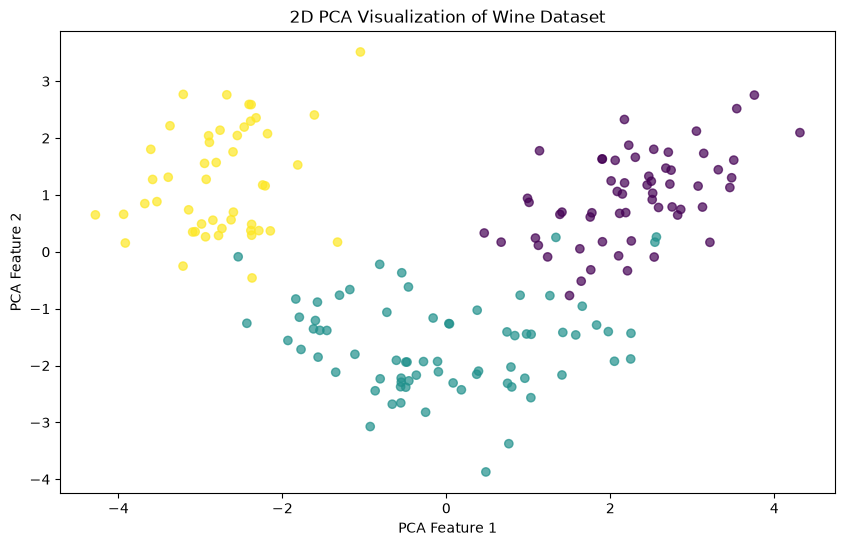

In [21]:
# 2D PCA
pca_2d = PCA(n_components=2)
pca_2d_features = pca_2d.fit_transform(scaled_X)

xs = pca_2d_features[:, 0]
ys = pca_2d_features[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(xs, ys, c=y, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.title('2D PCA Visualization of Wine Dataset')
plt.show()

### NMF

In [22]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

In [23]:
scaler = MinMaxScaler()
nmf_scaled_X = scaler.fit_transform(X)

nmf = NMF(n_components=3, random_state=42)
nmf_features = nmf.fit_transform(nmf_scaled_X)

df_nmf = pd.DataFrame(nmf_features, columns=['Feature 1', 'Feature 2', 'Feature 3'])
print(df_nmf.head())

   Feature 1  Feature 2  Feature 3
0   0.184412   0.020739   0.560865
1   0.136330   0.000000   0.448927
2   0.150627   0.102275   0.515327
3   0.256097   0.000000   0.529449
4   0.099372   0.238358   0.444532


In [24]:
# Find similar wines based on NMF features
from sklearn.preprocessing import normalize

normalized_features = normalize(nmf_features)

df_normalized = pd.DataFrame(normalized_features)

wine_0 = df_normalized.iloc[0]
similarities = df_normalized.dot(wine_0)

print("Top 5 most similar wines to the first wine:")
print(similarities.nlargest(5))  # Display top 5 most similar wines

Top 5 most similar wines to the first wine:
0     1.000000
51    0.999974
29    0.999927
42    0.999180
9     0.999163
dtype: float64
